# Contact Resistance

Contact resistance of a semiconductor-metal contact is found by measuring resistance at various lengths between contacts and extrapolating back to zero. The y-intercept of this line is twice the contact resistance.

In [1]:
import numpy as np

import suncal
from suncal.curvefit import CurveFit, Array

Length between contacts are defined in the `length` array, as designed on a test wafer. The `resistance` values were measured using a semiconductor parameter analyzer.

This analysis ignores any uncertainty in length or resistance measurements, and will estimate resistance uncertainty using the residual scatter about the best fit line.

In [2]:
length = np.array([0.25, 0.5, 1.0, 1.25, 2.0, 2.75, 5.25])
resistance = np.array([54.6, 65.1, 88.1, 106.2, 104.9, 162.3, 230.3])
arr = Array(length, resistance)
fit = CurveFit(arr)
result = fit.calculate()
result

|Parameter   | Nominal   | Standard Uncertainty  |
|-----------|---------|----------------------|
|b           | 35.0  | 2.8              |
|a           | 50.9  | 6.8              |

The basic fit results provide the slope (b) and intercept (a) values and their uncertainties.

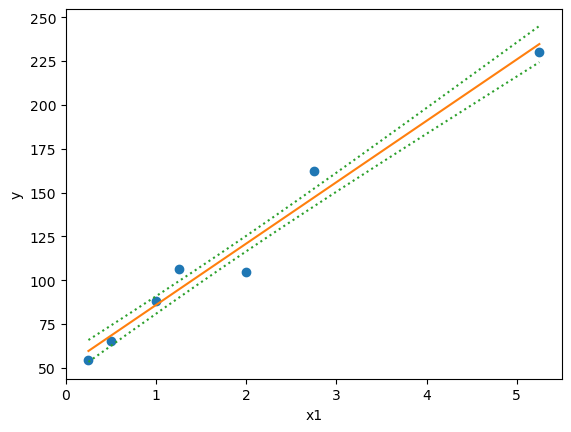

In [3]:
result.report.plot.summary()

The y-intercept (a) is the resistance due to two contacts. The value may also be accessed using the `y` function evaluated at 0, and `prediction_band` evaluated at 0 to get the uncertainty at 95% confidence.

In [4]:
result.y(0)

np.float64(50.910000000000004)

In [5]:
result.prediction_band(0)

np.float64(13.470269930480239)